## Notebook 2: Preprocessing and Baseline Model

Quick recap from the EDA: fraud is only about 0.17% of the data. That's why accuracy is such a bad metric to lean on here. A model that never predicts fraud at all would still look 99.8% accurate. Everything below is built around that fact.

In this notebook I'll do a small amount of preprocessing (scaling the two columns that aren't already scaled), split the data into train and test the right way for something this imbalanced, and train the simplest reasonable model, Logistic Regression, just to get a baseline number. Anything fancier I try afterward has to actually beat this to justify itself.

### Step 3: Preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the data fresh in this new notebook (each notebook runs independently -
# it doesn't remember variables from 01_eda.ipynb, even though it's the same project)
df = pd.read_csv('../data/creditcard.csv')

# V1-V28 are already scaled (they came out of PCA already standardized).
# Time and Amount were NOT touched, so we scale them ourselves.
scaler = StandardScaler()

# StandardScaler transforms values so the column has mean=0, std=1 -
# this puts Amount and Time on a comparable numeric range to the V-features,
# which matters for models like Logistic Regression that are sensitive to scale
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])  # replace raw dollar amounts with scaled values
df['Time_scaled'] = scaler.fit_transform(df[['Time']])      # replace raw seconds-elapsed with scaled values

# Drop the original unscaled columns now that we have scaled replacements
df = df.drop(['Amount', 'Time'], axis=1)

V1-V28 already have small, standardized ranges (roughly -20 to 20, centered near 0) because of how PCA transformed them originally. Amount and Time weren't touched though. Amount goes from $0 into the tens of thousands, and Time is in the hundreds of thousands of seconds. Logistic Regression is sensitive to raw scale, so a column with huge numbers can end up dominating the model's decisions just because its numbers are bigger, not because it's actually more predictive. Scaling puts everything on the same footing.

Tree-based models like Random Forest (coming in notebook 3) don't really need this since they're not distance-based, but it doesn't hurt them either. So I'll just scale once here and reuse the same dataset for every model.

In [2]:
# X = everything the model gets to look at (all columns except the answer)
# y = the answer we're trying to predict (0 = normal, 1 = fraud)
X = df.drop('Class', axis=1)
y = df['Class']

### Step 3.3 - Train/test split (with stratification)

In [3]:
from sklearn.model_selection import train_test_split

# Split the data into a training set (model learns from this) and a
# test set (we evaluate on this - the model never sees it during training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% of rows held out for testing, 80% for training
    random_state=42,     # fixes the "randomness" so you get the same split every time you run this
    stratify=y            # forces both sets to keep the same fraud ratio as the full dataset
)

# Check that stratify actually worked - both counts should be roughly
# 0.17% of their respective set sizes
print(f"Training fraud cases: {y_train.sum()}")
print(f"Test fraud cases: {y_test.sum()}")

Training fraud cases: 394
Test fraud cases: 98


test_size=0.2 splits the ~284,807 rows into roughly 227,845 for training and 56,962 for testing. The model only ever learns from the training rows. The test set is held back purely to check how it does on data it's never seen, which is the closest thing I have to simulating real, new transactions.

random_state=42 just makes the split reproducible. train_test_split shuffles before splitting, so without fixing this I'd get a different random split every time I re-ran the cell, and I wouldn't be able to compare results run to run. 42 doesn't mean anything special, it's just the common convention.

The important one here is stratify=y. With only 492 fraud cases out of 284,807 total, a plain random split could easily dump most of the fraud into one side by chance, say 450 in training and 42 in testing, or some other lopsided split. That would make my test results meaningless, since I'd be evaluating on a fraud rate that doesn't match reality. stratify=y forces both sets to keep roughly the same 0.17% fraud ratio. Sure enough, training comes out to 394 fraud cases and testing to 98, both close to what you'd expect.

### Step 4: Baseline Model - Logistic Regression

### Step 4.1 - Train it

In [4]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' tells the model to pay MORE attention to the rare
# class (fraud) during training, instead of treating every row equally.
# Without this, the model could get away with basically ignoring fraud
# entirely and still score well, since fraud is only 0.17% of the data.
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,        # how many optimization steps it's allowed to take to converge on an answer
    random_state=42        # same purpose as before - reproducible results
)

# .fit() is where the actual "learning" happens - the model looks at
# X_train (the features) alongside y_train (the correct answers) and
# adjusts itself to find patterns that separate fraud from normal
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

Despite the name, Logistic Regression is a classification model, not regression in the everyday sense. It outputs a probability between 0 and 1 that a transaction is fraud, based on a weighted combination of the input features. It's about as simple as models get, which is exactly why it's a good first thing to build. I need a number to compare fancier models against later. If something more complex can't beat this, the extra complexity isn't earning its keep.

max_iter=1000 just gives the model more attempts to converge. It finds its weights through an iterative search (try, check, adjust, repeat), and the default cap of 100 iterations is sometimes too low to fully settle with 30 features. Bumping it up avoids the failed to converge warning.

### Step 4.2 - Predict and evaluate

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



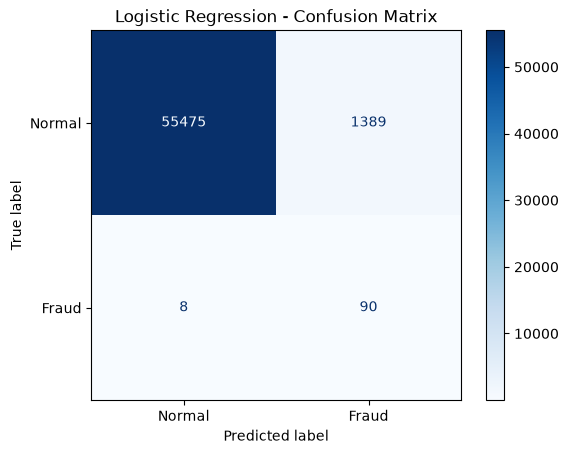

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ask the trained model to predict labels (0 or 1) for the test set -
# data it has never seen during training
y_pred = model.predict(X_test)

# classification_report prints precision, recall, and F1 for each class
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Build a confusion matrix: a 2x2 grid comparing predicted vs actual labels
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.savefig('../dashboard/logreg_confusion_matrix.png')
plt.show()

How to read the classification report: precision (fraud row) tells me, of everything the model flagged as fraud, what percent actually was fraud. Low precision means a lot of false alarms. Recall tells me, of everything that actually was fraud, what percent the model caught. Low recall means fraud slipping through. F1 is just a single number that balances the two, handy for comparing models at a glance.

For the confusion matrix: top-left is normal transactions correctly left alone, bottom-right is fraud correctly caught (the number I want to maximize), top-right is normal transactions wrongly flagged (annoying, but not dangerous), and bottom-left is fraud the model missed entirely, which is the costliest mistake since it means real fraud went through undetected.

I'm ignoring the overall accuracy number and the Normal row entirely. With an imbalance this extreme, both will look great no matter what the model actually does. Only the Fraud row's precision, recall, and F1 tell me anything useful, so those are the numbers I'm carrying forward as my baseline.

My baseline (Logistic Regression):

- Fraud precision: 0.06 (6%)
- Fraud recall: 0.92 (92%)
- Fraud F1: 0.11

Recall of 92% is genuinely good. The model caught about 90 of the 98 fraud cases in the test set, so very little fraud slipped through completely undetected.

Precision is where it falls apart. Of every 100 transactions flagged as fraud, only about 6 actually were. Working backward, catching ~90 real fraud cases at 6% precision means it flagged roughly 1,500 transactions total, so around 1,410 innocent transactions got wrongly flagged. That's not something a review team could realistically act on.

F1 of 0.11 just reflects how lopsided that tradeoff is, a strong recall paired with a really weak precision.

Makes sense why, though. class_weight='balanced' basically told the model "don't ignore the rare class," so it leaned hard toward flagging things as fraud rather than risk missing real cases. That's the right instinct for something like a medical screening, but for a bank, flagging 1,400+ legitimate transactions is a real cost. Angry customers, an overwhelmed review team.

This is my number to beat. Anything I try next should raise precision without tanking recall too much, or at least land on a more workable tradeoff than 6% precision at 92% recall.